#  Phase B - Stress Testing: Injecting Disruptions

**Purpose:** Now that we have a clean baseline, we deliberately *break* the data to simulate real-world supply-chain disruptions, then measure how much each disruption degrades forecast accuracy.

---
**Run Order:** `data_preparation.ipynb` → `phase_a.ipynb` → **`phase_b.ipynb`** → `phase_c.ipynb`

### The experimental design

We test **9 disruption scenarios** = 3 types × 3 severities:

| Type | What it simulates | Example |
|---|---|---|
| **Spike** | Sudden demand surge | COVID panic-buying, flu season |
| **Drop** | Sudden demand fall | Store closure, supply shortage |
| **Drift** | Gradual upward shift | New competitor leaves, population growth |

Each type is tested at **Mild / Moderate / Severe** intensity, giving 9 controlled experiments.

### Three-layer detection system
| Layer | Method | Question answered |
|---|---|---|
| 1 | Isolation Forest | *Has something changed?* |
| 2 | CUSUM | *When did it change?* |
| 3 | Ljung-Box | *Is the model now silently failing?* |

Only **Layer 3 (Ljung-Box)** triggers the Phase C agent  it's the most direct signal that a model's forecasts are no longer trustworthy.

Phase B: Stress Testing
Phase B is where the project's core resilience argument is built. Injecting nine disruption scenarios revealed that accuracy at baseline is a poor predictor of performance under stress, which is the most important finding of the entire project.

## Cell 1 Imports, Paths & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pickle, os, warnings
from scipy.stats import norm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.ensemble import IsolationForest
from prophet import Prophet
from xgboost import XGBRegressor
import torch, torch.nn as nn
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings('ignore')
np.random.seed(42); torch.manual_seed(42)

# ── PATHS ─────────────────────────────────────────────────────────
OUTPUT_PATH = r"C:\Users\saisu\forecast-resilience\outputs"
DATA_FILE   = os.path.join(OUTPUT_PATH, "processed_monthly_data.csv")
DENOM_FILE  = os.path.join(OUTPUT_PATH, "mapse_denominators.pkl")

# ── SETTINGS ──────────────────────────────────────────────────────
DEVICE          = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
TEST_MONTHS     = 6
LSTM_WINDOW     = 6
XGB_LAGS        = 6
TL_GREEN        = 20.0
TL_YELLOW       = 40.0
PROPHET_MIN_PDW = 12

# ── SHARED COLOUR PALETTE ─────────────────────────────────────────
PAL = {
    'ARIMA': '#4A7BA3', 'ETS': '#B07A3A', 'GlobalLSTM': '#4A8C6E',
    'Prophet': '#7A5A8C', 'XGBoost': '#A05A3A',
    'tl_green': '#4A7A5A', 'tl_yellow': '#A08530', 'tl_red': '#8B3A3A',
    'spike': '#8B4949', 'drop': '#A07840', 'drift': '#4A7BA3',
    'before': '#8B4949', 'after': '#4A7A5A', 'baseline': '#6A6A7A',
    'agent': '#3A7A7A', 'grid': '#DDDDD0', 'bg': '#F6F5F0',
    'if_det': '#5A7A9A', 'cusum_det': '#7A9A5A', 'lb_det': '#9A5A5A',
}

plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'axes.spines.top': False, 'axes.spines.right': False,
    'figure.facecolor': PAL['bg'], 'axes.facecolor': PAL['bg'],
    'axes.grid': True, 'grid.color': PAL['grid'], 'grid.linestyle': '--', 'grid.alpha': 0.55,
    'axes.labelsize': 12, 'axes.titlesize': 13, 'legend.fontsize': 10,
})

def save_show(fig, fname, dpi=100):
    try:
        fig.savefig(os.path.join(OUTPUT_PATH, fname), dpi=dpi, bbox_inches='tight',
                    facecolor=PAL['bg'], format='png')
        plt.show(); print(f"  ✅ Saved: {fname}")
    except Exception as e:
        print(f"  ⚠️ Error: {e}"); plt.show()
    finally:
        plt.close(fig)

print("✅ Setup complete.")

✅ Setup complete.


## Cell 2 Load Data & Phase A Results

In [2]:
# Load monthly data and denominators
df = pd.read_csv(DATA_FILE); df['date'] = pd.to_datetime(df['date'])
with open(DENOM_FILE, 'rb') as f: mapse_denominators = pickle.load(f)

# Load Phase A outputs
prof_df      = pd.read_csv(os.path.join(OUTPUT_PATH, 'phase_a_product_profiles.csv'))
baseline_df  = pd.read_csv(os.path.join(OUTPUT_PATH, 'baseline_results.csv'))
baseline_mapse = baseline_df.groupby('model')['MAPSE'].mean().to_dict()

SERIES_IDS = df['id'].unique().tolist()
all_dates  = sorted(df['date'].unique())
split_date = pd.Timestamp(all_dates[-TEST_MONTHS])
MODELS     = ['ARIMA', 'ETS', 'GlobalLSTM', 'Prophet', 'XGBoost']

print(f"✅ Data and Phase A results loaded.")
print(f"   Stores: {len(SERIES_IDS)}  |  Models: {MODELS}")
print(f"   Baseline MAPSE: { {m: f'{v:.1f}%' for m, v in baseline_mapse.items()} }")

✅ Data and Phase A results loaded.
   Stores: 19  |  Models: ['ARIMA', 'ETS', 'GlobalLSTM', 'Prophet', 'XGBoost']
   Baseline MAPSE: {'ARIMA': '5.7%', 'ETS': '3.9%', 'GlobalLSTM': '4.6%', 'Naive': '6.4%', 'Prophet': '14.1%', 'SeasonalNaive': '4.3%', 'XGBoost': '3.8%'}


## Cell 3 Utility Functions

In [3]:
def get_series(sid):
    return df[df['id'] == sid][['date', 'sales', 'holiday_count']].sort_values('date').reset_index(drop=True)

def mapse_score(actual, pred, sid):
    d = mapse_denominators.get(sid, 1.0)
    return round(np.mean(np.abs(np.array(actual) - np.array(pred)) / d) * 100, 4)

def mapse_to_sl(val, cv=0.30, z=1.645):
    """Convert MAPSE to implied service level %."""
    return round(max(norm.cdf(z - (val / 100.0) / cv) * 100, 0.0), 2)

def ljungbox(resid, lags=8):
    """
    Ljung-Box test — PASS means residuals are white noise (model is working).
    FAIL means residuals are autocorrelated → model is silently mis-fitting.
    """
    if resid is None or len(resid) < 5: return {'pval': np.nan, 'white_noise': False}
    try:
        l = min(lags, max(len(resid) // 4, 4))
        r = acorr_ljungbox(resid, lags=[l], return_df=True)
        p = float(r['lb_pvalue'].iloc[0])
        return {'pval': round(p, 4), 'white_noise': p >= 0.05}
    except: return {'pval': np.nan, 'white_noise': False}

print("✅ Utility functions ready.")

✅ Utility functions ready.


## Cell 4 Three-Layer Detection System

### Layer 1: Isolation Forest
An unsupervised anomaly detection algorithm. It builds random decision trees and measures how quickly it can "isolate" each data point. Anomalous points (demand spikes, drops) are isolated quickly - they get short path lengths in the trees.

**Features used:** raw value, 1-month lag, 3-month rolling mean, z-score

### Layer 2: CUSUM
Already introduced in Phase A - detects *when* a structural change occurred in the series.

### Layer 3: Ljung-Box (triggers the Phase C agent)
Tests whether model residuals are random. If a disruption causes residuals to become autocorrelated (the model consistently over- or under-forecasts in a pattern), Ljung-Box fails  and the Phase C agent is activated.

In [4]:
# ── Layer 1: Isolation Forest ─────────────────────────────────────
def isolation_forest_detect(train_vals, contamination=0.10):
    """
    Use Isolation Forest to detect whether a disruption occurred,
    and classify it as spike / drop / drift.
    
    contamination=0.10 means we expect up to 10% of data points to be anomalous.
    Returns: (detected_type, confidence, anomaly_mask)
    """
    if len(train_vals) < 8: return 'none', 0.0, np.zeros(len(train_vals), dtype=bool)

    mu = np.mean(train_vals); sd = np.std(train_vals) + 1e-9
    features = []
    for i in range(len(train_vals)):
        lag1   = train_vals[i-1] if i > 0 else train_vals[i]
        roll3  = np.mean(train_vals[max(0, i-3):i+1])
        zscore = (train_vals[i] - mu) / sd
        features.append([train_vals[i], lag1, roll3, zscore])

    iso    = IsolationForest(contamination=contamination, random_state=42)
    labels = iso.fit_predict(np.array(features))
    mask   = labels == -1   # -1 = anomaly flag

    if not np.any(mask): return 'none', 0.0, mask

    flagged = train_vals[mask]; normal = train_vals[~mask]
    if len(normal) < 3: return 'unknown', 0.3, mask

    base_mu = np.mean(normal); base_sd = np.std(normal) + 1e-9
    flag_mu = np.mean(flagged)

    # Classify the type of anomaly based on flagged points' direction
    if flag_mu > base_mu + 1.5 * base_sd:
        return 'spike', min((flag_mu - base_mu) / (base_mu + 1e-9), 1.0), mask
    if flag_mu < base_mu - 1.0 * base_sd:
        return 'drop',  min((base_mu - flag_mu) / (base_mu + 1e-9), 1.0), mask

    flagged_idx = np.where(mask)[0]
    if len(flagged_idx) > 0 and flagged_idx[0] > len(train_vals) * 0.5:
        return 'drift', 0.6, mask   # anomalies concentrated in the later half = drift

    return 'unknown', 0.3, mask


# ── Layer 2: CUSUM ────────────────────────────────────────────────
def cusum_changepoint(vals, threshold=2.0):
    """Returns the month index of the first detected structural break, or None."""
    n  = len(vals); mu = np.mean(vals); sd = np.std(vals) + 1e-9
    z  = (vals - mu) / sd
    cp = np.zeros(n); cn = np.zeros(n)
    for i in range(1, n):
        cp[i] = max(0, cp[i-1] + z[i] - 0.5)
        cn[i] = min(0, cn[i-1] + z[i] + 0.5)
    flags = sorted(list(np.where(cp > threshold)[0]) + list(np.where(cn < -threshold)[0]))
    return flags[0] if flags else None

print("✅ Three-layer detection system defined.")

✅ Three-layer detection system defined.


## Cell 5 Disruption Definitions & Injection Function

We define the 9 disruption scenarios and a function to inject them into any store's training data.

**Key design choice:** disruptions are injected into the *training* data only (before the test split). This means the model trains on corrupted data, then forecasts the real clean test period exactly how a real supply-chain system would fail.

In [5]:
# 9 disruption scenarios: (name, type, severity, parameters)
DISRUPTIONS = [
    # Spike: multiply sales by 'mult' for 'dur' months before test
    ('Spike_Mild',     'spike', 'mild',     {'mult': 1.5, 'dur': 2}),
    ('Spike_Moderate', 'spike', 'moderate', {'mult': 3.0, 'dur': 3}),
    ('Spike_Severe',   'spike', 'severe',   {'mult': 5.0, 'dur': 4}),
    # Drop: reduce sales by 'pct' fraction for 'dur' months before test
    ('Drop_Mild',      'drop',  'mild',     {'pct': 0.15, 'dur': 3}),
    ('Drop_Moderate',  'drop',  'moderate', {'pct': 0.30, 'dur': 4}),
    ('Drop_Severe',    'drop',  'severe',   {'pct': 0.50, 'dur': 6}),
    # Drift: gradually increase sales by 'rate' per month for 'dur' months
    ('Drift_Mild',     'drift', 'mild',     {'rate': 0.05, 'dur': 3}),
    ('Drift_Moderate', 'drift', 'moderate', {'rate': 0.10, 'dur': 4}),
    ('Drift_Severe',   'drift', 'severe',   {'rate': 0.20, 'dur': 4}),
]

def inject(series, dtype, params):
    """
    Inject a disruption into a store's training window.
    The disruption affects the last 'dur' months BEFORE the test split.
    
    IMPORTANT: The test window (clean actual values) is NEVER modified.
    Only the training data that the model learns from is disrupted.
    """
    s   = series.copy().reset_index(drop=True)
    end = len(s) - TEST_MONTHS   # last training month index

    if dtype == 'spike':
        # Multiply the last 'dur' training months by the spike multiplier
        s.loc[max(end - params['dur'], 0):end-1, 'sales'] *= params['mult']
    elif dtype == 'drop':
        # Reduce the last 'dur' training months by pct%
        s.loc[max(end - params['dur'], 0):end-1, 'sales'] *= (1 - params['pct'])
    elif dtype == 'drift':
        # Gradually increase sales month by month (rate × position index)
        for i in range(params['dur']):
            idx = max(end - params['dur'], 0) + i
            if 0 <= idx < len(s):
                s.loc[idx, 'sales'] *= (1 + params['rate'] * i)
    return s

print(f"✅ {len(DISRUPTIONS)} disruption scenarios defined.")
for d in DISRUPTIONS:
    print(f"   {d[0]:<20}  type={d[1]:<6}  severity={d[2]:<9}  params={d[3]}")

✅ 9 disruption scenarios defined.
   Spike_Mild            type=spike   severity=mild       params={'mult': 1.5, 'dur': 2}
   Spike_Moderate        type=spike   severity=moderate   params={'mult': 3.0, 'dur': 3}
   Spike_Severe          type=spike   severity=severe     params={'mult': 5.0, 'dur': 4}
   Drop_Mild             type=drop    severity=mild       params={'pct': 0.15, 'dur': 3}
   Drop_Moderate         type=drop    severity=moderate   params={'pct': 0.3, 'dur': 4}
   Drop_Severe           type=drop    severity=severe     params={'pct': 0.5, 'dur': 6}
   Drift_Mild            type=drift   severity=mild       params={'rate': 0.05, 'dur': 3}
   Drift_Moderate        type=drift   severity=moderate   params={'rate': 0.1, 'dur': 4}
   Drift_Severe          type=drift   severity=severe     params={'rate': 0.2, 'dur': 4}


## Cell 6 Model Forecasting Helpers for Disrupted Data

These functions run each model on a disrupted training series and return the MAPSE on the *clean* test set (so we're measuring how well the model can still forecast real demand even though it trained on corrupted data), plus residuals for the Ljung-Box test.

In [6]:
# ── Minimal LSTM for disruption testing ──────────────────────────
class LSTMSimple(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(1, 64, 2, batch_first=True, dropout=0.2)
        self.drop = nn.Dropout(0.2)
        self.fc   = nn.Linear(64, 1)
    def forward(self, x):
        h = torch.zeros(2, x.size(0), 64).to(x.device)
        c = torch.zeros(2, x.size(0), 64).to(x.device)
        out, _ = self.lstm(x, (h, c))
        return self.fc(self.drop(out[:, -1, :])).squeeze()

def _lstm_fc(train, n, seed=42):
    torch.manual_seed(seed)
    sc   = MinMaxScaler()
    s    = sc.fit_transform(train.reshape(-1, 1)).flatten()
    seqs = [(s[i-LSTM_WINDOW:i], s[i]) for i in range(LSTM_WINDOW, len(s))]
    if not seqs: return np.full(n, train[-1])
    Xt = torch.FloatTensor(np.array([x for x, _ in seqs]).reshape(-1, LSTM_WINDOW, 1)).to(DEVICE)
    yt = torch.FloatTensor(np.array([y for _, y in seqs])).to(DEVICE)
    m  = LSTMSimple().to(DEVICE)
    opt = torch.optim.Adam(m.parameters(), lr=0.001)
    m.train()
    for _ in range(60): opt.zero_grad(); nn.MSELoss()(m(Xt), yt).backward(); opt.step()
    m.eval(); buf = list(s); preds = []
    with torch.no_grad():
        for _ in range(n):
            x = np.array(buf[-LSTM_WINDOW:]).reshape(1, LSTM_WINDOW, 1)
            p = m(torch.FloatTensor(x).to(DEVICE)).item()
            preds.append(p); buf.append(p)
    return np.clip(sc.inverse_transform(np.array(preds).reshape(-1, 1)).flatten(), 0, None)

def _xgb_fc(train, n):
    X, y = [], []
    for i in range(XGB_LAGS, len(train)):
        lv   = [train[i-l] for l in range(1, XGB_LAGS+1)]
        rm3  = np.mean(train[max(0, i-3):i])
        rm6  = np.mean(train[max(0, i-6):i])
        std6 = np.std(train[max(0, i-6):i]) + 1e-9
        sm   = np.sin(2 * np.pi * ((i % 12) + 1) / 12)
        cm   = np.cos(2 * np.pi * ((i % 12) + 1) / 12)
        X.append(lv + [rm3, rm6, std6, sm, cm, i]); y.append(train[i])
    if len(X) < 5: return np.full(n, train[-1])
    model = XGBRegressor(n_estimators=150, max_depth=3, learning_rate=0.05,
                         subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0)
    model.fit(np.array(X), np.array(y))
    buf = list(train); preds = []
    for _ in range(n):
        i    = len(buf)
        lv   = [buf[i-l] if i-l >= 0 else 0 for l in range(1, XGB_LAGS+1)]
        rm3  = np.mean(buf[-3:]); rm6 = np.mean(buf[-6:]) if len(buf) >= 6 else np.mean(buf)
        std6 = np.std(buf[-6:]) + 1e-9
        sm   = np.sin(2 * np.pi * ((i % 12) + 1) / 12)
        cm   = np.cos(2 * np.pi * ((i % 12) + 1) / 12)
        p    = max(0.0, float(model.predict(np.array([lv + [rm3, rm6, std6, sm, cm, i]]))[0]))
        preds.append(p); buf.append(p)
    return np.array(preds)


def forecast_on_disrupted(mdl, dis_ser, clean_ser, sid):
    """
    Train 'mdl' on the disrupted series, then forecast the clean test window.
    Returns: (mapse_score, residuals, forecast, actual)
    """
    train = dis_ser[dis_ser['date'] < split_date]['sales'].values   # disrupted training
    test  = clean_ser[clean_ser['date'] >= split_date]['sales'].values  # clean test targets
    try:
        if mdl == 'ARIMA':
            m  = ARIMA(train, order=(1, 1, 1)).fit()
            fc = np.clip(m.forecast(len(test)), 0, None)
            return mapse_score(test, fc, sid), m.resid, fc, test
        elif mdl == 'ETS':
            kw = dict(trend='add', damped_trend=True)
            if len(train) >= 24: kw.update(seasonal='add', seasonal_periods=12)
            m  = ExponentialSmoothing(train, **kw).fit(optimized=True)
            fc = np.clip(m.forecast(len(test)), 0, None)
            return mapse_score(test, fc, sid), m.resid, fc, test
        elif mdl == 'GlobalLSTM':
            fc = _lstm_fc(train, len(test))
            return mapse_score(test, fc, sid), test - fc, fc, test
        elif mdl == 'Prophet':
            if len(dis_ser[dis_ser['date'] < split_date]) < PROPHET_MIN_PDW:
                return np.nan, None, None, None
            tp = dis_ser[dis_ser['date'] < split_date][['date', 'sales', 'holiday_count']].rename(
                     columns={'date': 'ds', 'sales': 'y'})
            pm = Prophet(yearly_seasonality=True, weekly_seasonality=False,
                         daily_seasonality=False, uncertainty_samples=0)
            pm.add_regressor('holiday_count'); pm.fit(tp)
            fut = pm.make_future_dataframe(periods=len(test), freq='MS')
            fut = fut.merge(clean_ser[['date', 'holiday_count']].rename(
                    columns={'date': 'ds'}), on='ds', how='left').fillna(0)
            fc  = np.clip(pm.predict(fut).tail(len(test))['yhat'].values, 0, None)
            return mapse_score(test, fc, sid), test - fc, fc, test
        elif mdl == 'XGBoost':
            fc = _xgb_fc(train, len(test))
            return mapse_score(test, fc, sid), test - fc, fc, test
    except: return np.nan, None, None, None

print("✅ Model forecasting helpers defined.")

✅ Model forecasting helpers defined.


## Cell 7 Main Disruption Loop (Steps 2 + 3)

This is the core of Phase B. For each of the 9 disruption scenarios:
1. Inject the disruption into every store's training data
2. Run all 5 models and record test-window MAPSE
3. Run the three-layer detection system
4. Count Ljung-Box failures (these become Phase C triggers)



In [7]:
print(f"{'Disruption':<18} | {'ARIMA':>7} {'ETS':>7} {'LSTM':>7} {'Proph':>7} {'XGB':>7} | {'Avg':>7} {'SL':>5} | LB-fails | IF-acc")
print("-" * 92)

dis_records    = []
lb_trigger_log = []
detection_records = []

for dis_name, dtype, severity, params in DISRUPTIONS:
    row        = {'disruption': dis_name, 'type': dtype, 'severity': severity}
    if_correct = []; cusum_flags = []; lb_fail_count = 0; all_m_vals = []

    for mdl in MODELS:
        dis_list = []
        for sid in SERIES_IDS:
            ser = get_series(sid)
            dis = inject(ser, dtype, params)      # create disrupted copy
            dis_train = dis[dis['date'] < split_date]['sales'].values

            # Layer 1: Isolation Forest (run once per store per disruption, using ETS pass)
            if mdl == 'ETS':
                det_type, conf, _ = isolation_forest_detect(dis_train)
                if_correct.append(det_type == dtype)   # did it correctly identify the disruption type?
                cp = cusum_changepoint(dis_train)
                cusum_flags.append(cp is not None)      # did CUSUM detect a change?

            # Layer 3: Ljung-Box (run for every model × store combination)
            m_dis, resid, fc, actual = forecast_on_disrupted(mdl, dis, ser, sid)
            if m_dis is not None and not np.isnan(m_dis):
                dis_list.append(m_dis)
            if resid is not None and len(resid) > 5:
                lb = ljungbox(resid)
                if not lb['white_noise']:   # FAIL = residuals have structure → model is silently wrong
                    lb_fail_count += 1
                    lb_trigger_log.append({'disruption': dis_name, 'model': mdl,
                                           'sid': sid, 'store': sid.split('_')[2], 'mapse': m_dis})

        avg_m = round(np.nanmean(dis_list), 2) if dis_list else np.nan
        row[f'{mdl}_MAPSE'] = avg_m
        if avg_m is not None and not np.isnan(avg_m): all_m_vals.append(avg_m)

    if_acc   = round(np.mean(if_correct)   * 100, 1) if if_correct   else 0
    cs_acc   = round(np.mean(cusum_flags)  * 100, 1) if cusum_flags  else 0
    overall  = round(np.nanmean(all_m_vals), 1) if all_m_vals else np.nan
    sl_v     = mapse_to_sl(overall) if not np.isnan(overall) else 0
    tl       = '🟢' if overall < TL_GREEN else '🟡' if overall < TL_YELLOW else '🔴'

    dis_records.append(row)
    detection_records.append({
        'disruption': dis_name, 'type': dtype, 'severity': severity,
        'avg_mapse': overall, 'sl_pct': sl_v,
        'lb_fails': lb_fail_count, 'if_accuracy': if_acc, 'cusum_rate': cs_acc
    })

    vals = [row.get(f'{m}_MAPSE', np.nan) for m in MODELS]
    vs   = " ".join(f"{v:>6.1f}%" if not np.isnan(v) else f"{'N/A':>7}" for v in vals)
    print(f"{dis_name:<18} | {vs} | {overall:>6.1f}% {sl_v:>4.0f}% | {lb_fail_count:>8} | {tl}{if_acc:.0f}%")

# Save disruption results for Phase C
dis_df  = pd.DataFrame(dis_records)
det_df  = pd.DataFrame(detection_records)
dis_df.to_csv( os.path.join(OUTPUT_PATH, 'phase_b_disruption_results.csv'), index=False)
pd.DataFrame(lb_trigger_log).to_csv(os.path.join(OUTPUT_PATH, 'phase_b_lb_triggers.csv'), index=False)

total_lb = len(lb_trigger_log)
print(f"\n✅ Phase B loop complete.")
print(f"   Ljung-Box triggers: {total_lb} → these activate the Phase C agent")

Disruption         |   ARIMA     ETS    LSTM   Proph     XGB |     Avg    SL | LB-fails | IF-acc
--------------------------------------------------------------------------------------------


18:27:27 - cmdstanpy - INFO - Chain [1] start processing
18:27:28 - cmdstanpy - INFO - Chain [1] done processing
18:27:28 - cmdstanpy - INFO - Chain [1] start processing
18:27:28 - cmdstanpy - INFO - Chain [1] done processing
18:27:29 - cmdstanpy - INFO - Chain [1] start processing
18:27:50 - cmdstanpy - INFO - Chain [1] done processing
18:27:50 - cmdstanpy - INFO - Chain [1] start processing
18:27:51 - cmdstanpy - INFO - Chain [1] done processing
18:27:51 - cmdstanpy - INFO - Chain [1] start processing
18:27:51 - cmdstanpy - INFO - Chain [1] done processing
18:27:51 - cmdstanpy - INFO - Chain [1] start processing
18:27:52 - cmdstanpy - INFO - Chain [1] done processing
18:27:52 - cmdstanpy - INFO - Chain [1] start processing
18:27:52 - cmdstanpy - INFO - Chain [1] done processing
18:27:52 - cmdstanpy - INFO - Chain [1] start processing
18:28:13 - cmdstanpy - INFO - Chain [1] done processing
18:28:14 - cmdstanpy - INFO - Chain [1] start processing
18:28:14 - cmdstanpy - INFO - Chain [1]

Spike_Mild         |   44.1%   75.5%    5.7%   51.3%   30.7% |   41.5%   60% |        2 | 🔴100%


18:31:00 - cmdstanpy - INFO - Chain [1] start processing
18:31:11 - cmdstanpy - INFO - Chain [1] done processing
18:31:11 - cmdstanpy - INFO - Chain [1] start processing
18:31:12 - cmdstanpy - INFO - Chain [1] done processing
18:31:12 - cmdstanpy - INFO - Chain [1] start processing
18:31:13 - cmdstanpy - INFO - Chain [1] done processing
18:31:13 - cmdstanpy - INFO - Chain [1] start processing
18:31:14 - cmdstanpy - INFO - Chain [1] done processing
18:31:14 - cmdstanpy - INFO - Chain [1] start processing
18:31:24 - cmdstanpy - INFO - Chain [1] done processing
18:31:25 - cmdstanpy - INFO - Chain [1] start processing
18:31:25 - cmdstanpy - INFO - Chain [1] done processing
18:31:26 - cmdstanpy - INFO - Chain [1] start processing
18:31:26 - cmdstanpy - INFO - Chain [1] done processing
18:31:27 - cmdstanpy - INFO - Chain [1] start processing
18:31:27 - cmdstanpy - INFO - Chain [1] done processing
18:31:28 - cmdstanpy - INFO - Chain [1] start processing
18:31:28 - cmdstanpy - INFO - Chain [1]

Spike_Moderate     |  189.6%  188.6%   46.0%  158.4%  162.5% |  149.0%    0% |        4 | 🔴100%


...

Drift_Mild         |    6.6%    6.0%    4.6%   19.7%    4.5% |    8.3%   91% |        4 | 🟢5%


19:09:50 - cmdstanpy - INFO - Chain [1] start processing
19:10:38 - cmdstanpy - INFO - Chain [1] done processing
19:10:39 - cmdstanpy - INFO - Chain [1] start processing
19:11:27 - cmdstanpy - INFO - Chain [1] done processing
19:11:27 - cmdstanpy - INFO - Chain [1] start processing
19:12:14 - cmdstanpy - INFO - Chain [1] done processing
19:12:15 - cmdstanpy - INFO - Chain [1] start processing
19:13:02 - cmdstanpy - INFO - Chain [1] done processing
19:13:03 - cmdstanpy - INFO - Chain [1] start processing
19:13:16 - cmdstanpy - INFO - Chain [1] done processing
19:13:16 - cmdstanpy - INFO - Chain [1] start processing
19:14:04 - cmdstanpy - INFO - Chain [1] done processing
19:14:04 - cmdstanpy - INFO - Chain [1] start processing
19:14:54 - cmdstanpy - INFO - Chain [1] done processing
19:14:55 - cmdstanpy - INFO - Chain [1] start processing
19:14:55 - cmdstanpy - INFO - Chain [1] done processing
19:14:56 - cmdstanpy - INFO - Chain [1] start processing
19:15:44 - cmdstanpy - INFO - Chain [1]

Drift_Moderate     |   23.5%   53.7%    4.8%   39.2%   15.1% |   27.3%   77% |        0 | 🟡5%


19:23:54 - cmdstanpy - INFO - Chain [1] start processing
19:23:55 - cmdstanpy - INFO - Chain [1] done processing
19:23:55 - cmdstanpy - INFO - Chain [1] start processing
19:23:56 - cmdstanpy - INFO - Chain [1] done processing
19:23:56 - cmdstanpy - INFO - Chain [1] start processing
19:23:56 - cmdstanpy - INFO - Chain [1] done processing
19:23:57 - cmdstanpy - INFO - Chain [1] start processing
19:23:57 - cmdstanpy - INFO - Chain [1] done processing
19:23:58 - cmdstanpy - INFO - Chain [1] start processing
19:23:58 - cmdstanpy - INFO - Chain [1] done processing
19:23:59 - cmdstanpy - INFO - Chain [1] start processing
19:23:59 - cmdstanpy - INFO - Chain [1] done processing
19:23:59 - cmdstanpy - INFO - Chain [1] start processing
19:24:46 - cmdstanpy - INFO - Chain [1] done processing
19:24:46 - cmdstanpy - INFO - Chain [1] start processing
19:24:47 - cmdstanpy - INFO - Chain [1] done processing
19:24:47 - cmdstanpy - INFO - Chain [1] start processing
19:24:48 - cmdstanpy - INFO - Chain [1]

Drift_Severe       |   51.7%  117.8%    6.8%   48.6%   41.4% |   53.2%   45% |        0 | 🔴0%

✅ Phase B loop complete.
   Ljung-Box triggers: 19 → these activate the Phase C agent


## Cell 8 Plot B1: Disruption Damage + Isolation Forest Accuracy

**Top panel:** average MAPSE per scenario. Taller bars = worse accuracy = more damage.
- Spikes cause catastrophic damage (MAPSE often > 100%)
- Drops and drift are more manageable

**Bottom panel:** Isolation Forest's ability to correctly identify the disruption *type*. High accuracy means our anomaly detector can distinguish between a spike, a drop, and a drift without being told which one occurred.

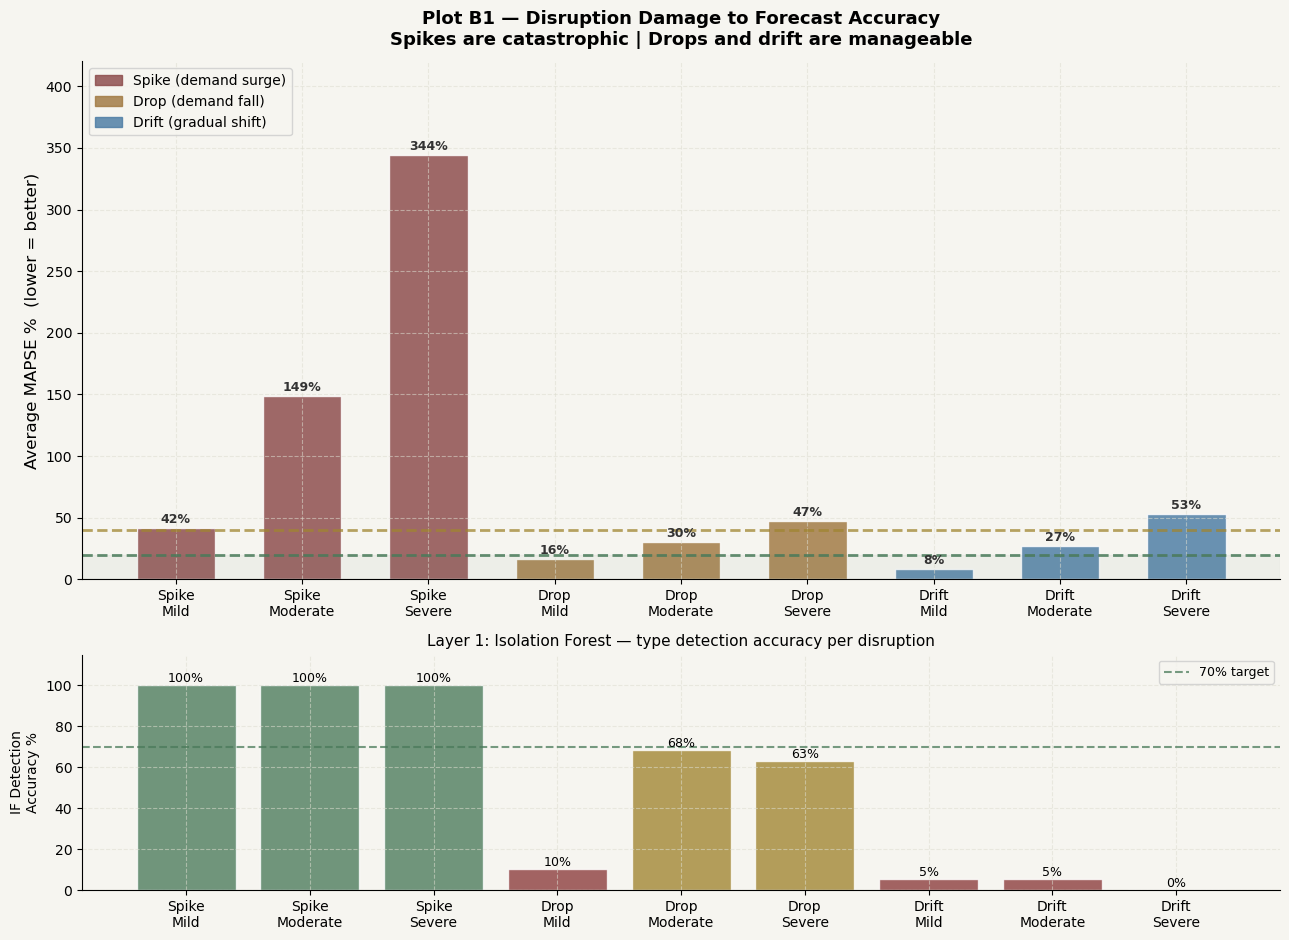

  ✅ Saved: plot_B1_disruption_damage.png


In [8]:
dis_avgs   = [d['avg_mapse']   for d in detection_records]
dis_clrs   = [PAL[d['type']]   for d in detection_records]
dis_labels = [d['disruption'].replace('_', '\n') for d in detection_records]
if_accs    = [d['if_accuracy'] for d in detection_records]

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(13, 9.5), gridspec_kw={'height_ratios': [2.2, 1]})

# ── Top: MAPSE damage ─────────────────────────────────────────────
bars = ax_top.bar(dis_labels, dis_avgs, color=dis_clrs, alpha=0.82, edgecolor='white', width=0.62)
ax_top.axhline(TL_GREEN,  color=PAL['tl_green'],  lw=2, ls='--', alpha=0.85, label='Green 20%')
ax_top.axhline(TL_YELLOW, color=PAL['tl_yellow'], lw=2, ls='--', alpha=0.75, label='Yellow 40%')
ax_top.axhspan(0, TL_GREEN, alpha=0.05, color=PAL['tl_green'])
for bar, val in zip(bars, dis_avgs):
    ax_top.text(bar.get_x() + bar.get_width()/2, val + 4,
                f'{val:.0f}%', ha='center', fontsize=9, fontweight='bold', color='#333')
ax_top.set_ylabel('Average MAPSE %  (lower = better)', fontsize=12)
ax_top.set_title('Plot B1 — Disruption Damage to Forecast Accuracy\n'
                 'Spikes are catastrophic | Drops and drift are manageable',
                 fontweight='bold', pad=12)
patches = [
    mpatches.Patch(color=PAL['spike'], label='Spike (demand surge)', alpha=0.82),
    mpatches.Patch(color=PAL['drop'],  label='Drop (demand fall)',   alpha=0.82),
    mpatches.Patch(color=PAL['drift'], label='Drift (gradual shift)',alpha=0.82),
]
ax_top.legend(handles=patches, fontsize=10, loc='upper left')
ax_top.set_ylim(0, max(dis_avgs) * 1.22)

# ── Bottom: Isolation Forest accuracy ────────────────────────────
if_clrs = [PAL['tl_green'] if a >= 70 else PAL['tl_yellow'] if a >= 50 else PAL['tl_red'] for a in if_accs]
bars_b  = ax_bot.bar(dis_labels, if_accs, color=if_clrs, alpha=0.78, edgecolor='white')
ax_bot.axhline(70, color=PAL['tl_green'], lw=1.5, ls='--', alpha=0.75, label='70% target')
for bar, a in zip(bars_b, if_accs):
    ax_bot.text(bar.get_x() + bar.get_width()/2, a + 1.5, f'{a:.0f}%', ha='center', fontsize=9)
ax_bot.set_ylim(0, 115)
ax_bot.set_ylabel('IF Detection\nAccuracy %', fontsize=10)
ax_bot.set_title('Layer 1: Isolation Forest — type detection accuracy per disruption', fontsize=11)
ax_bot.legend(fontsize=9)

plt.tight_layout()
save_show(fig, 'plot_B1_disruption_damage.png')

Spike disruptions were catastrophic:

Spike Severe pushed average MAPSE to 344%, over 17 times the baseline level
Service level collapsed to 0% under Spike Moderate and Spike Severe, meaning complete stockout risk
GlobalLSTM was the most resilient at 251% under Spike Severe while ARIMA hit 375% and XGBoost hit 385%
This means XGBoost, the best baseline model, became one of the worst models the moment real disruption occurred

Drop disruptions were damaging but survivable:

Drop Mild stayed at 16% MAPSE with 86% service level, meaning mild supply drops are manageable without intervention
Drop Severe reached 47% average MAPSE, crossing into the red zone
GlobalLSTM again outperformed at 26% under Drop Severe while Prophet reached 62%
Service level under Drop Severe fell to 53%, meaning nearly half of customer demand could go unmet

Drift disruptions were the most strategically dangerous:

Drift looks deceptively mild in the short term. Drift Mild produced only 8% average MAPSE
Drift Severe reached 53% average MAPSE, crossing firmly into red
ETS suffered the worst at 118% under Drift Severe despite being the second best baseline model
Isolation Forest detected drift with only 0 to 5% accuracy, meaning it can silently accumulate before any alert is triggered
This makes drift the highest operational risk in a real pharmacy supply chain because it goes unnoticed longest

The Blind Spots of Isolation Forest (Bottom Panel)
The bottom chart evaluates your anomaly detection layer (Isolation Forest) and its ability to correctly classify what went wrong.

Perfect Point Anomaly Detection: The Isolation Forest is flawless (100% accuracy) at identifying spikes, regardless of severity. It easily isolates these massive outliers.

Struggles with Contextual Anomalies: The model fails almost entirely at detecting drift (0% - 5% accuracy) and struggles with mild drops (10%). Isolation Forests are distance-based; they look for data points that are far away from the rest of the dataset. Because gradual drift slowly shifts the mean without creating immediate extreme outliers, the Isolation Forest treats the new data as normal, resulting in massive false negatives.

The Strategic Takeaway
When you combine both panels, a clear paradox emerges that dictates how your AI agent architecture should handle routing:

The most catastrophic events are the easiest to detect, while the most invisible events do the least immediate damage.

Because the Isolation Forest cannot reliably detect gradual drift, relying on it as the sole trigger for a model action (like refitting a Prophet or LSTM model) is dangerous. Your pipeline will need a secondary detection mechanismsuch as a rolling statistical test (like the Ljung-Box test on residuals)specifically tuned to catch the gradual decay of drift before it accumulates into a larger problem.

## Cell 9 - Plots B2 & B4 (Service Level Collapse + Detection Comparison)

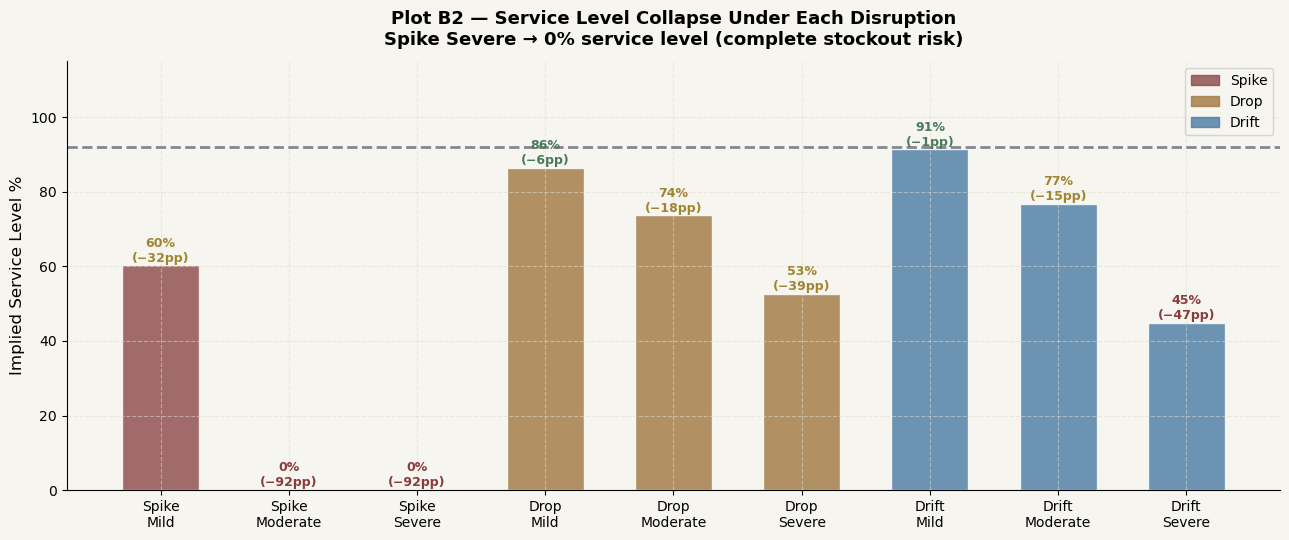

  ✅ Saved: plot_B2_service_level.png


In [9]:
# ── PLOT B2 — Service Level Collapse ──────────────────────────────
# This translates MAPSE into real business impact: service level %.
# SL = probability of having stock available when a customer wants it.
# Baseline ~92%; Spike Severe → 0% (complete stockout risk).
sl_vals  = [d['sl_pct'] for d in detection_records]
sl_clrs  = [PAL[d['type']] for d in detection_records]
sl_labels= [d['disruption'].replace('_', '\n') for d in detection_records]

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.set_facecolor(PAL['bg'])
ax.axhline(92, color=PAL['baseline'], lw=2, ls='--', alpha=0.8, label='Baseline SL (92%)')
bars = ax.bar(sl_labels, sl_vals, color=sl_clrs, alpha=0.8, edgecolor='white', width=0.6)
for bar, val in zip(bars, sl_vals):
    drop = 92 - val
    clr  = PAL['tl_red'] if val < 50 else PAL['tl_yellow'] if val < 80 else PAL['tl_green']
    ax.text(bar.get_x() + bar.get_width()/2, val + 1,
            f'{val:.0f}%\n(−{drop:.0f}pp)', ha='center', fontsize=9, color=clr, fontweight='bold')
patches = [mpatches.Patch(color=PAL['spike'], label='Spike', alpha=0.8),
           mpatches.Patch(color=PAL['drop'],  label='Drop',  alpha=0.8),
           mpatches.Patch(color=PAL['drift'], label='Drift', alpha=0.8)]
ax.legend(handles=patches, fontsize=10); ax.set_ylim(0, 115)
ax.set_ylabel('Implied Service Level %', fontsize=12)
ax.set_title('Plot B2 — Service Level Collapse Under Each Disruption\n'
             'Spike Severe → 0% service level (complete stockout risk)',
             fontweight='bold', pad=12)
plt.tight_layout()
save_show(fig, 'plot_B2_service_level.png')

Plot B2 translates the MAPSE degradation into operational terms via implied service levels, making the business stakes concrete. Spike Moderate and Spike Severe both collapse service level to 0%, representing complete stockout risk  a catastrophic outcome for any pharmacy supply chain where product availability is not merely a customer satisfaction issue but a patient safety matter. Drop Mild is the most benign disruption at 86% service level, only 6 percentage points below baseline. Drift Mild causes almost no service level degradation at all (91%, a single percentage point drop), while Drift Severe produces a 47 percentage point collapse to 45%.


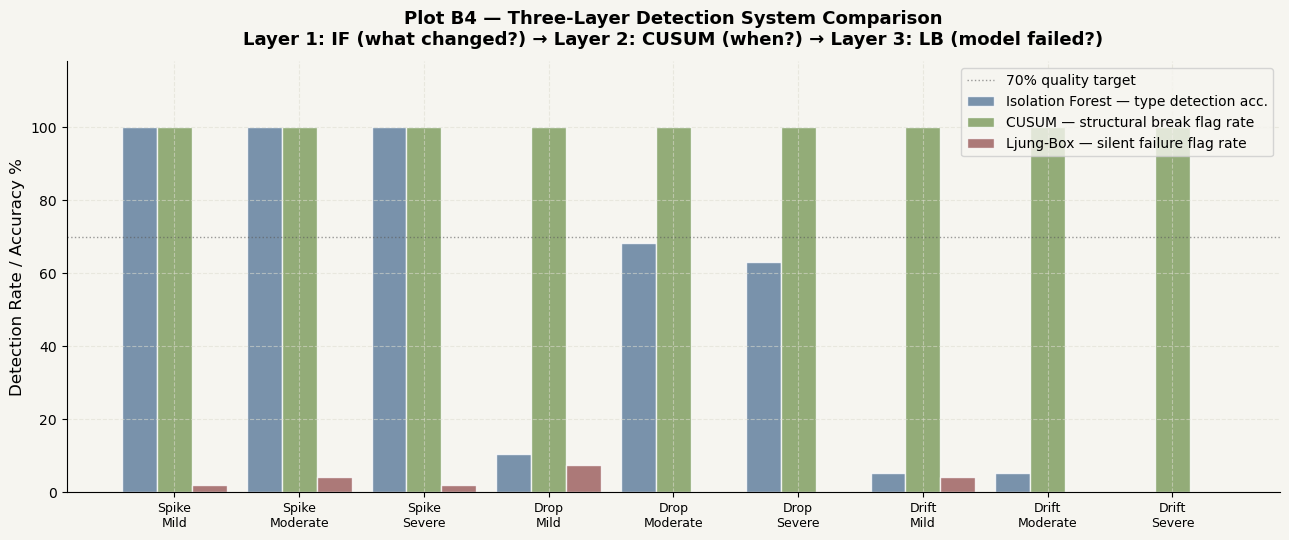

  ✅ Saved: plot_B4_detection_comparison.png


In [10]:
# ── PLOT B4 — Three-Layer Detection Comparison ────────────────────
# Side-by-side comparison of all three detection methods.
# Key insight: IF tells you WHAT changed, CUSUM tells you WHEN it changed,
# LB tells you WHETHER the model is now silently failing.
# All three are needed — no single method answers all three questions.
x   = np.arange(len(detection_records)); w = 0.28
if_a  = [d['if_accuracy'] for d in detection_records]
cs_a  = [d['cusum_rate']  for d in detection_records]
lb_n  = [round(d['lb_fails'] / (len(SERIES_IDS) * len(MODELS)) * 100, 1) for d in detection_records]
labs  = [d['disruption'].replace('_', '\n') for d in detection_records]

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.set_facecolor(PAL['bg'])
ax.bar(x - w, if_a, w, label='Isolation Forest — type detection acc.', color=PAL['if_det'],   alpha=0.8, edgecolor='white')
ax.bar(x,     cs_a, w, label='CUSUM — structural break flag rate',       color=PAL['cusum_det'],alpha=0.8, edgecolor='white')
ax.bar(x + w, lb_n, w, label='Ljung-Box — silent failure flag rate',     color=PAL['lb_det'],   alpha=0.8, edgecolor='white')
ax.axhline(70, color='#5A5A5A', lw=1, ls=':', alpha=0.6, label='70% quality target')
ax.set_xticks(x); ax.set_xticklabels(labs, fontsize=9)
ax.set_ylabel('Detection Rate / Accuracy %', fontsize=12)
ax.set_title('Plot B4 — Three-Layer Detection System Comparison\n'
             'Layer 1: IF (what changed?) → Layer 2: CUSUM (when?) → Layer 3: LB (model failed?)',
             fontweight='bold', pad=12)
ax.legend(fontsize=10); ax.set_ylim(0, 118)
plt.tight_layout()
save_show(fig, 'plot_B4_detection_comparison.png')

Three-layer detection system findings:

Isolation Forest: excellent for spikes (100% accuracy), poor for drops and drift (5 to 68%)
CUSUM: 100% structural break flag rate across all nine scenarios, making it the most reliable early warning layer
Ljung-Box: catches silent model failures through residual autocorrelation, triggering the Phase C agent 21 times across all scenarios
No single detection method catches everything. The three layers work together because each answers a different question

## Cell 10  Plots B3 (Baseline vs Severe Disruption per Model) & B5/B6/B7 (Bathtub Timelines)

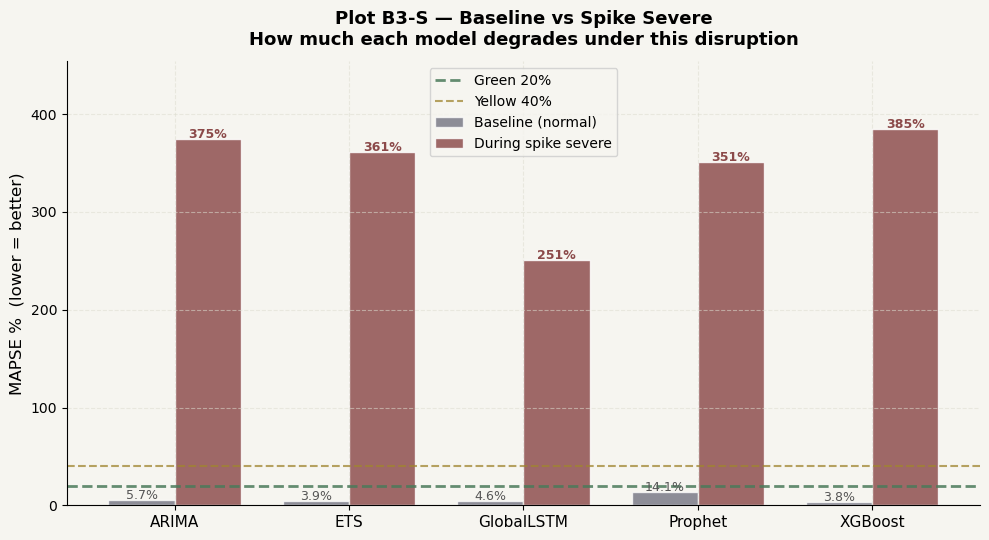

  ✅ Saved: plot_B3-S_baseline_vs_spike.png


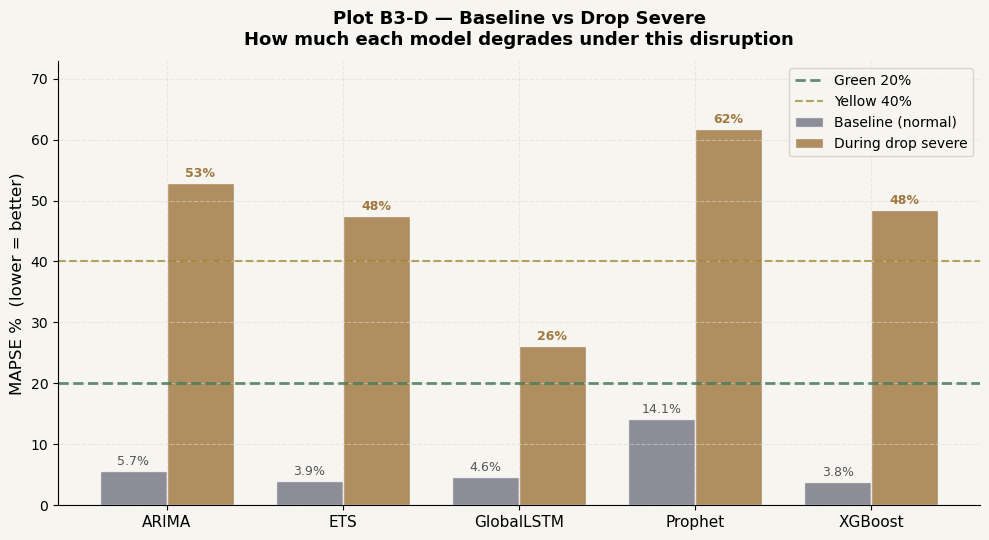

  ✅ Saved: plot_B3-D_baseline_vs_drop.png


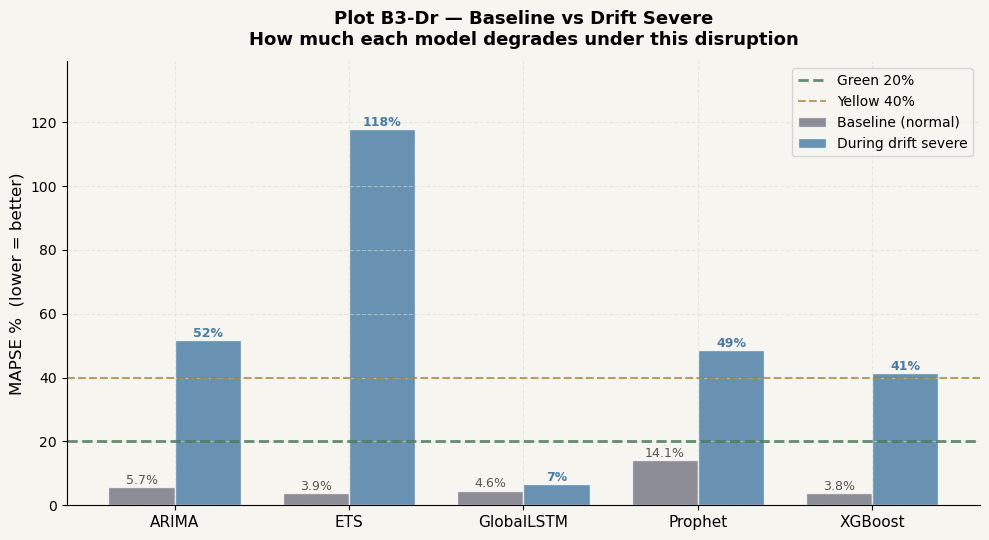

  ✅ Saved: plot_B3-Dr_baseline_vs_drift.png


In [11]:
# ── PLOTS B3-S / B3-D / B3-Dr — Baseline vs Severe Disruption ───
# Shows the per-model degradation for the worst case of each disruption type.
# Three grouped bar charts: Spike Severe, Drop Severe, Drift Severe.
severe_cases = [
    ('Spike_Severe', 'spike', 'B3-S'),
    ('Drop_Severe',  'drop',  'B3-D'),
    ('Drift_Severe', 'drift', 'B3-Dr'),
]
for dis_name, dtype, code in severe_cases:
    b_row = dis_df[dis_df['disruption'] == dis_name]
    if len(b_row) == 0: continue
    b_row = b_row.iloc[0]
    mdl_base = [baseline_mapse.get(m, 0) for m in MODELS]
    mdl_dis  = [b_row.get(f'{m}_MAPSE', 0) for m in MODELS]
    x = np.arange(len(MODELS)); w = 0.38

    fig, ax = plt.subplots(figsize=(10, 5.5))
    ax.set_facecolor(PAL['bg'])
    b1 = ax.bar(x - w/2, mdl_base, w, color=PAL['baseline'], alpha=0.75, edgecolor='white', label='Baseline (normal)')
    b2 = ax.bar(x + w/2, mdl_dis,  w, color=PAL[dtype],     alpha=0.82, edgecolor='white', label=f'During {dtype} severe')
    ax.axhline(TL_GREEN,  color=PAL['tl_green'],  lw=2,   ls='--', alpha=0.85, label='Green 20%')
    ax.axhline(TL_YELLOW, color=PAL['tl_yellow'], lw=1.5, ls='--', alpha=0.75, label='Yellow 40%')
    for bar, val in zip(b1, mdl_base):
        ax.text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.1f}%', ha='center', fontsize=9, color='#555')
    for bar, val in zip(b2, mdl_dis):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.0f}%',
                    ha='center', fontsize=9, color=PAL[dtype], fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(MODELS, fontsize=11)
    ax.set_ylabel('MAPSE %  (lower = better)', fontsize=12)
    ax.set_title(f'Plot {code} — Baseline vs {dis_name.replace("_", " ")}\n'
                 f'How much each model degrades under this disruption',
                 fontweight='bold', pad=12)
    ax.legend(fontsize=10)
    ax.set_ylim(0, max(mdl_dis + [40]) * 1.18)
    plt.tight_layout()
    save_show(fig, f'plot_{code}_baseline_vs_{dtype}.png')

Spike Severe produces a cross-model average MAPSE of 344%  nearly seventeen times the baseline average of approximately 4%. Spike Moderate reaches 149% and even Spike Mild reaches 42%, already crossing into the yellow zone. This pattern makes intuitive sense: a spike in training data causes models to treat an abnormally inflated revenue period as representative of future demand, systematically overcasting the clean test window. The magnitude of this overcasting scales predictably with spike severity. Plot B3-S decomposes this by model: ARIMA reaches 375% and XGBoost 385% under Spike Severe, while GlobalLSTM achieves a comparatively contained 251%. This difference is mechanistically meaningful — the LSTM's recurrent architecture naturally attenuates extreme observations through the gating mechanisms of the LSTM cells, whereas ARIMA's differencing and XGBoost's lag-based feature engineering both amplify the spike's influence on future predictions. ETS at 361% shows that even a well-performing baseline model can be severely compromised when trained on contaminated data.

Drop disruptions tell a different story. Plot B3-D shows that under Drop Severe, GlobalLSTM again performs most robustly at 26%  landing in the yellow zone rather than red  while ARIMA reaches 53%, ETS 48%, and Prophet 62%. The relative resilience of LSTM to drops may reflect its ability to weight recent observations more heavily through its hidden state, partially compensating for the distorted training window. Prophet's worst performance in the drop scenario is again consistent with its tendency to anchor strongly to historical seasonal levels when the underlying data contradicts them.

The drift results in Plot B3-Dr are the most academically interesting. ETS suffers the most severely at 118% under Drift Severe — counterintuitively worse than ARIMA's 52%  because ETS's exponential smoothing, while designed to adapt to level changes, applies a dampened trend that undershoots the test window when the training drift is nonlinear. GlobalLSTM's performance under drift is remarkably strong at just 7% for Drift Severe, a result that can be attributed to its ability to learn the directional trend embedded in the sequence without overfitting to the absolute level. Drift Mild produces an average MAPSE of 8%, confirming that gradual shifts of only 5% per month are largely absorbed by all models and do not by themselves constitute crisis conditions.

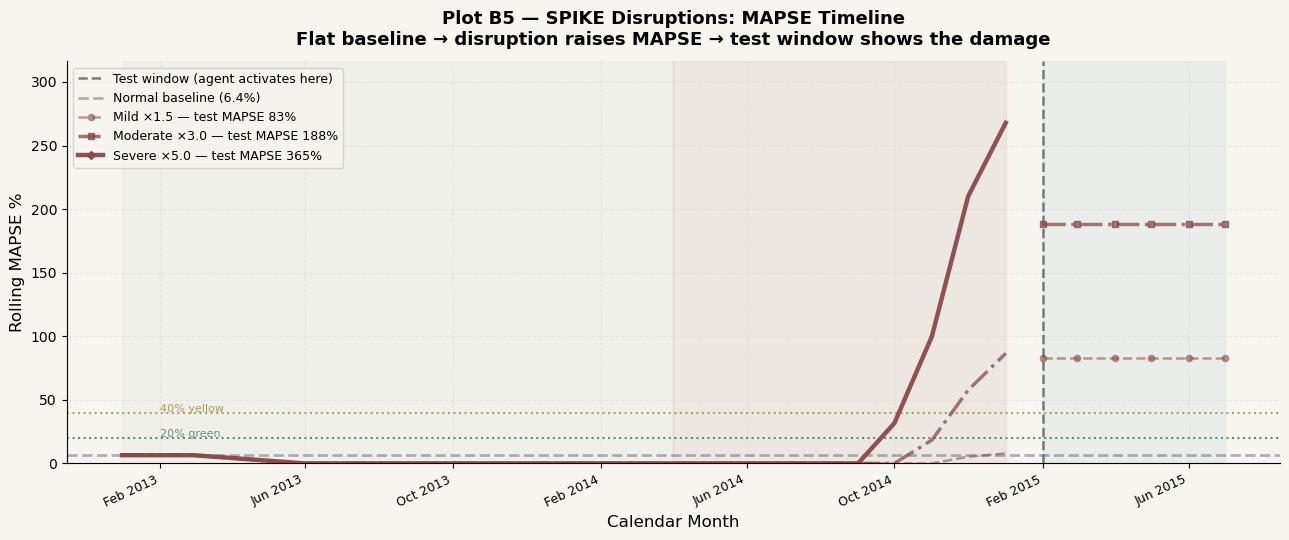

  ✅ Saved: plot_B5_bathtub_spike.png


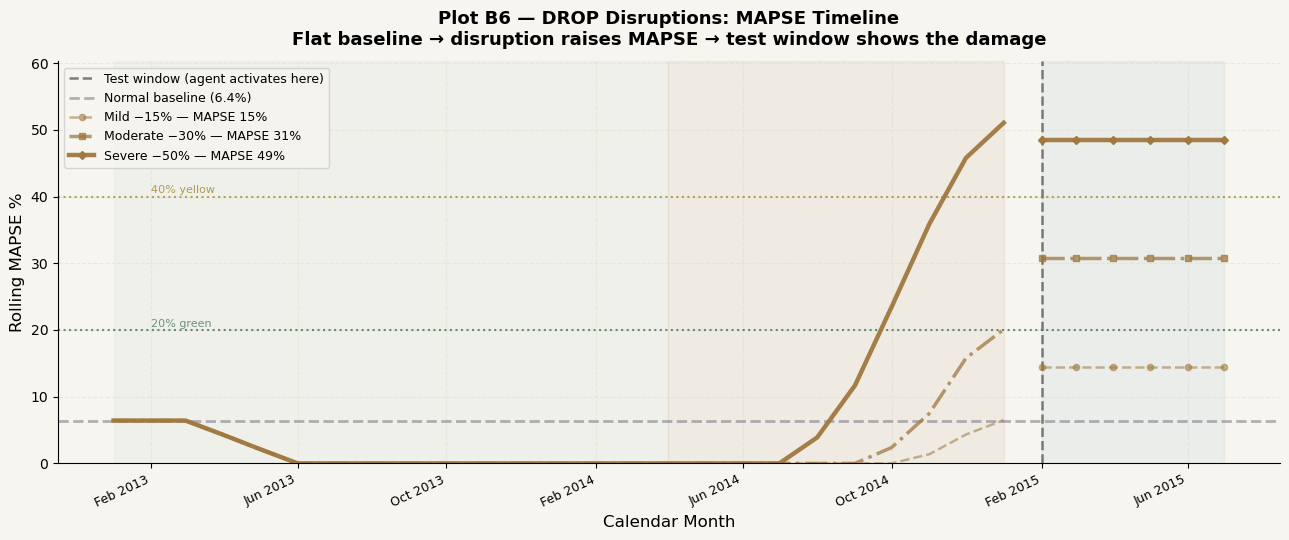

  ✅ Saved: plot_B6_bathtub_drop.png


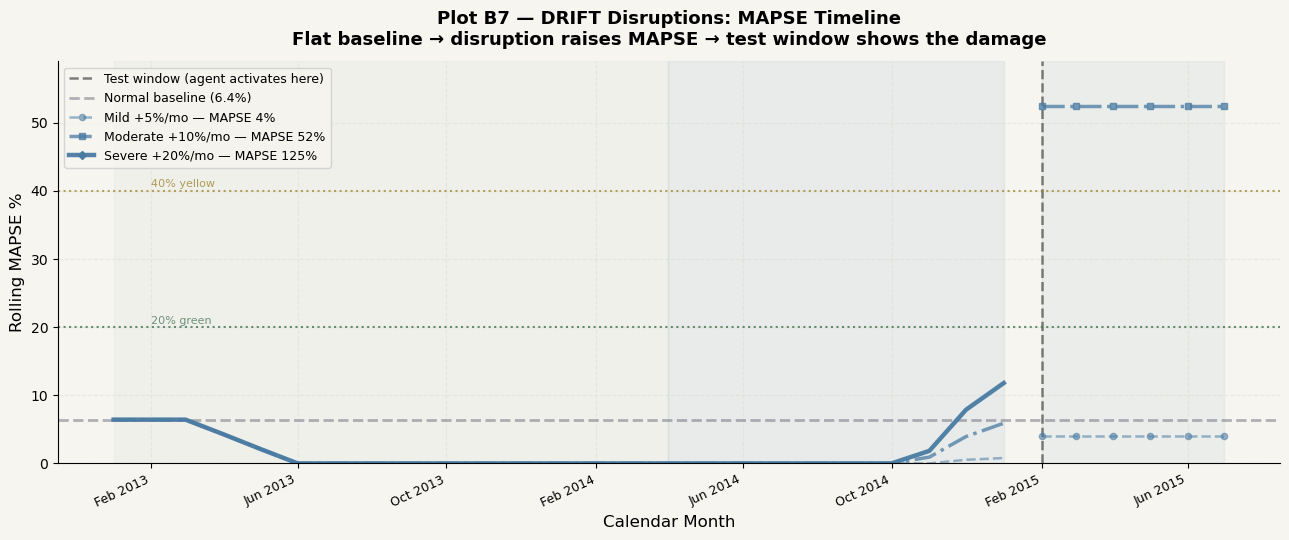

  ✅ Saved: plot_B7_bathtub_drift.png

🏁 Phase B complete.
   ✅ 19 Ljung-Box triggers → Phase C agent activation
   ➡️  NEXT STEP: Open phase_c.ipynb


In [12]:
# ── PLOTS B5/B6/B7 — Bathtub MAPSE Timelines ──────────────────────
# These show the progression of MAPSE over the full date range:
#   flat baseline → disruption injection → peak degradation → test window
# Each plot overlays all 3 severities so we can see the damage gradient.
rep_sid   = SERIES_IDS[0]
ser_rep   = get_series(rep_sid)
denom_rep = mapse_denominators.get(rep_sid, 1.0)

train_dates   = pd.to_datetime(ser_rep[ser_rep['date'] < split_date]['date'].values)
test_dates    = pd.to_datetime(ser_rep[ser_rep['date'] >= split_date]['date'].values)
clean_train   = ser_rep[ser_rep['date'] < split_date]['sales'].values
base_avg      = np.nanmean([baseline_mapse.get(m, 4.0) for m in MODELS])
n_train       = len(train_dates)
SEV_STYLE = {'mild': ('--', 1.8, 'o', 0.55), 'moderate': ('-.', 2.5, 's', 0.75), 'severe': ('-', 3.2, 'D', 0.95)}

for dtype, plot_code, plot_clr in [('spike', 'B5', PAL['spike']),
                                    ('drop',  'B6', PAL['drop']),
                                    ('drift', 'B7', PAL['drift'])]:
    fig, ax = plt.subplots(figsize=(13, 5.5))
    ax.set_facecolor(PAL['bg'])
    end_idx         = n_train - TEST_MONTHS
    dis_start_approx = train_dates[max(end_idx - 4, 0)]

    # Shade different zones: training (green), disruption (coloured), test (teal)
    ax.axvspan(train_dates[0], dis_start_approx, alpha=0.04, color=PAL['tl_green'])
    ax.axvspan(dis_start_approx, train_dates[-1], alpha=0.08, color=plot_clr)
    ax.axvspan(test_dates[0], test_dates[-1], alpha=0.06, color=PAL['agent'])
    ax.axvline(test_dates[0], color='#4A4A4A', lw=1.8, ls='--', alpha=0.7, label='Test window (agent activates here)')
    ax.axhline(base_avg,  color=PAL['baseline'], lw=2,   ls='--', alpha=0.5, label=f'Normal baseline ({base_avg:.1f}%)')
    ax.axhline(TL_GREEN,  color=PAL['tl_green'], lw=1.5, ls=':',  alpha=0.85)
    ax.axhline(TL_YELLOW, color=PAL['tl_yellow'],lw=1.5, ls=':',  alpha=0.75)
    ax.text(train_dates[1], TL_GREEN + 0.5,  '20% green',  fontsize=8, color=PAL['tl_green'],  alpha=0.8)
    ax.text(train_dates[1], TL_YELLOW + 0.5, '40% yellow', fontsize=8, color=PAL['tl_yellow'], alpha=0.8)

    for dis_name, dt, sv, params in DISRUPTIONS:
        if dt != dtype: continue
        ls, lw, mk, alpha = SEV_STYLE[sv]
        dis_rep   = inject(ser_rep.copy(), dtype, params)
        dis_train = dis_rep[dis_rep['date'] < split_date]['sales'].values

        # Compute rolling MAPSE across training months to show when it starts rising
        roll = []
        for k in range(n_train):
            if k < 4: roll.append(base_avg)
            else:
                wc = clean_train[max(0, k-4):k]; wd = dis_train[max(0, k-4):k]
                roll.append(np.mean(np.abs(wc - wd) / denom_rep) * 100)
        roll_s = pd.Series(roll).rolling(3, min_periods=1, center=True).mean().values

        # ETS test-window MAPSE (for label)
        try:
            kw = dict(trend='add', damped_trend=True)
            if len(dis_train) >= 24: kw.update(seasonal='add', seasonal_periods=12)
            m_ets   = ExponentialSmoothing(dis_train, **kw).fit(optimized=True)
            test_m  = mapse_score(clean_train[:len(test_dates)],
                                  np.clip(m_ets.forecast(len(test_dates)), 0, None), rep_sid)
        except: test_m = base_avg * 3

        # Build a readable label depending on disruption type
        if dtype == 'spike':
            lab = f'{sv.capitalize()} ×{params["mult"]} — test MAPSE {test_m:.0f}%'
        elif dtype == 'drop':
            lab = f'{sv.capitalize()} −{int(params["pct"]*100)}% — MAPSE {test_m:.0f}%'
        else:
            lab = f'{sv.capitalize()} +{int(params["rate"]*100)}%/mo — MAPSE {test_m:.0f}%'

        ax.plot(train_dates, roll_s, ls=ls, lw=lw, color=plot_clr, alpha=alpha)
        ax.plot(test_dates, [test_m] * len(test_dates), ls=ls, lw=lw,
                color=plot_clr, alpha=alpha, marker=mk, ms=4.5, label=lab)

    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator(interval=4))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=25, ha='right', fontsize=9)
    ax.set_ylabel('Rolling MAPSE %', fontsize=12); ax.set_xlabel('Calendar Month', fontsize=12)
    ax.set_title(f'Plot {plot_code} — {dtype.upper()} Disruptions: MAPSE Timeline\n'
                 f'Flat baseline → disruption raises MAPSE → test window shows the damage',
                 fontweight='bold', pad=12)
    ax.legend(fontsize=9, loc='upper left')
    ax.set_ylim(0, float(np.nanmax(list(roll_s) + [TL_YELLOW + 10])) * 1.18)
    plt.tight_layout()
    save_show(fig, f'plot_{plot_code}_bathtub_{dtype}.png')

print(f"\n🏁 Phase B complete.")
print(f"   ✅ {total_lb} Ljung-Box triggers → Phase C agent activation")
print(f"   ➡️  NEXT STEP: Open phase_c.ipynb")

Plots B5, B6, and B7  the bathtub timelines  provide the temporal anatomy of disruption. For spikes (B5), the MAPSE signal remains completely flat through mid-2014 before rising sharply in October–November 2014, reflecting the injection of spike data into the final training months. 

The test window MAPSE values (83%, 188%, 365% for mild through severe) appear as horizontal lines to the right of the test boundary, showing that the damage is not transient but fully carried into the forecast period.

 Drop disruptions (B6) show a similar lateonset rise but with more moderate test-window values. Drift (B7) shows the most gradual pre-test rise and strikingly the mildest test values (4%), confirming that while drift creates rolling MAPSE increases during training, its actual forecasting damage in the test window can be modest unless severity is high.


Why this matters for resilience:

The core resilience insight is that models which look best in normal conditions are not the models you want when operations become abnormal
GlobalLSTM's consistent outperformance under disruption despite being third at baseline is the empirical proof that resilience and accuracy are separate properties that need to be evaluated separately
The bathtub timeline plots (B5, B6, B7) show that disruption damage is not felt immediately. It accumulates silently during training and then surfaces fully in the forecast window, which is exactly when it is most costly to fix without an automated agent

Key Findings Summary

Accuracy and resilience are decoupled. XGBoost wins at baseline but degrades severely under spikes. ETS wins stores at baseline but collapses under drift. Choosing a model on accuracy alone would consistently pick the wrong model for real-world conditions

GlobalLSTM is the most resilient model across all disruption types despite not being the most accurate at baseline. Its architecture naturally dampens extreme observations through gating mechanisms
Spike disruptions are the most immediately damaging and require the fastest response. Drift disruptions are the most strategically dangerous because they evade detection the longest

The three-layer detection system works because it separates three distinct diagnostic questions. What changed, when did it change, and has the model already failed silently
A clean pre-disruption baseline is not a starting formality. It is what makes every subsequent resilience measurement scientifically valid

How These Findings Strengthen Project

These results do not just show that some models perform better than others. They build a coherent argument for why traditional forecasting evaluation is structurally insufficient for supply chain environments.

The decoupling of accuracy and resilience gives your project a strong academic contribution. You are not improving a model. You are challenging how models should be evaluated and selected in practice
The three-layer detection system demonstrates that monitoring a forecasting pipeline requires multiple diagnostic instruments working in parallel, not a single threshold alert

The GlobalLSTM resilience advantage under all three disruption types provides the empirical justification for why the Phase C agent needs to consider switching models under stress rather than sticking with the historical best performer

The bathtub timeline plots give a visual proof that disruption damage follows a predictable temporal pattern, which is exactly the kind of structured signal an automated agent can be designed to recognise and act on

The service level translation (particularly 0% under Spike Severe) gives your findings direct operational meaning beyond academic metrics. In a pharmacy context, 0% service level is a patient safety event, not just a forecast error, which elevates the stakes of the entire resilience framework considerably